In [1]:
import sys
import os

# Obtener el directorio padre (ruta base del proyecto)
base_path = os.path.abspath('..')
if base_path not in sys.path:
    sys.path.append(base_path)

import matplotlib.pyplot as plt
import paths, read_img, data_augmentation, plots_utils
import random

# Rutas del proyecto
data_dir = paths.data_dir()
avance1_base = paths.fase1_aumento_de_datos_dir()
train_path = os.path.join(data_dir, 'train','images')


In [2]:
data_fun = data_augmentation.DataAugmentation(seed=30)

In [3]:
sel_images = [
    "328_png.rf.f26a0e556c05be000d358049026dde41.jpg",
    "1621_jpg.rf.417979b453ee933362f94207434fe154.jpg",
    "675_jpg.rf.6fdfbd3b7cffec42d277db7ec26a0f6e.jpg",
    "108_png.rf.ddda45ea75a7ebf59c9401a851942dd7.jpg",
    "1434_png.rf.9ea381f722af353db538f889558848c1.jpg"
]

sel_images_paths = [os.path.join(train_path, name) for name in sel_images]

In [4]:
# Leer las imágenes seleccionadas en formato escala de grises
images_bn = [read_img.read_image_as_grayscale(path) for path in sel_images_paths]

In [5]:
factores = [(2,2), (5,4), (1.5,0.75), (0.75,1.5), (2,0.5)]
res_esc = {}
for ind, img in enumerate(images_bn):
    img = data_fun.scale(img, x_factor=factores[ind][0], y_factor=factores[ind][1])
    nombre = 'imagen_' + str(ind+1)
    res_esc[nombre] = img

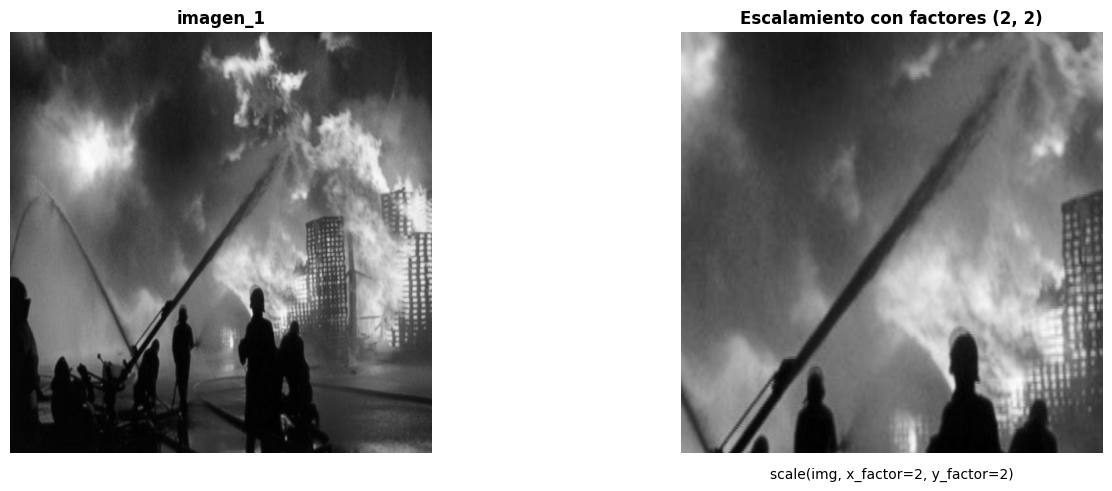

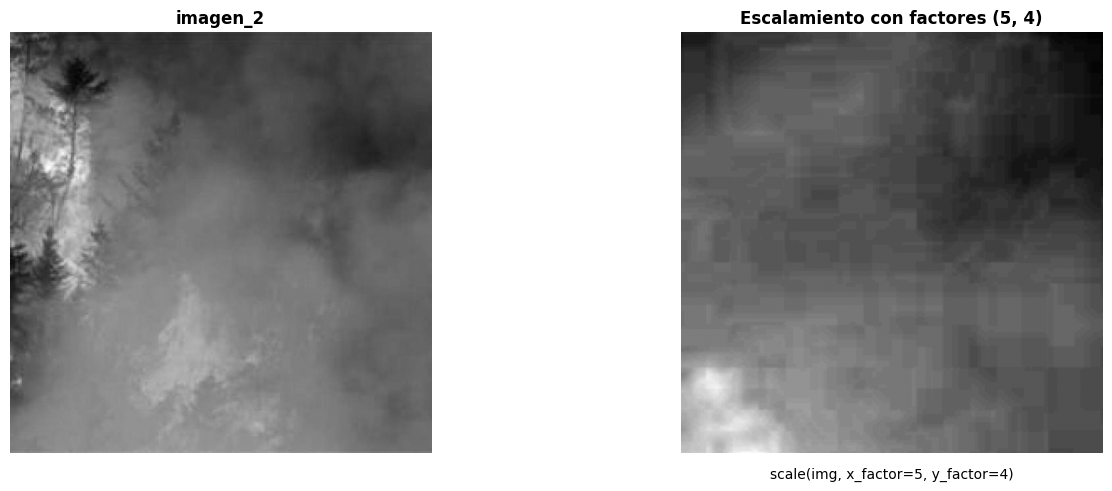

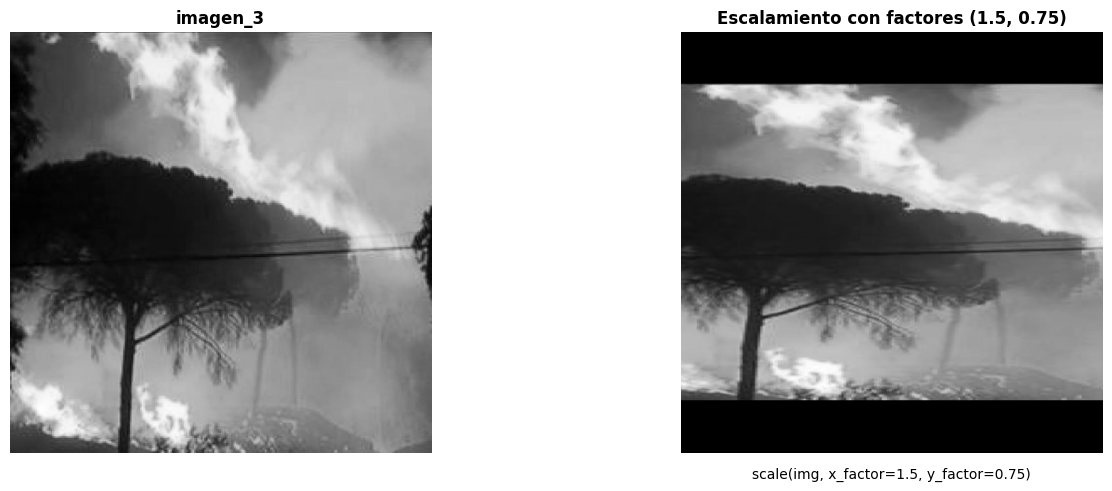

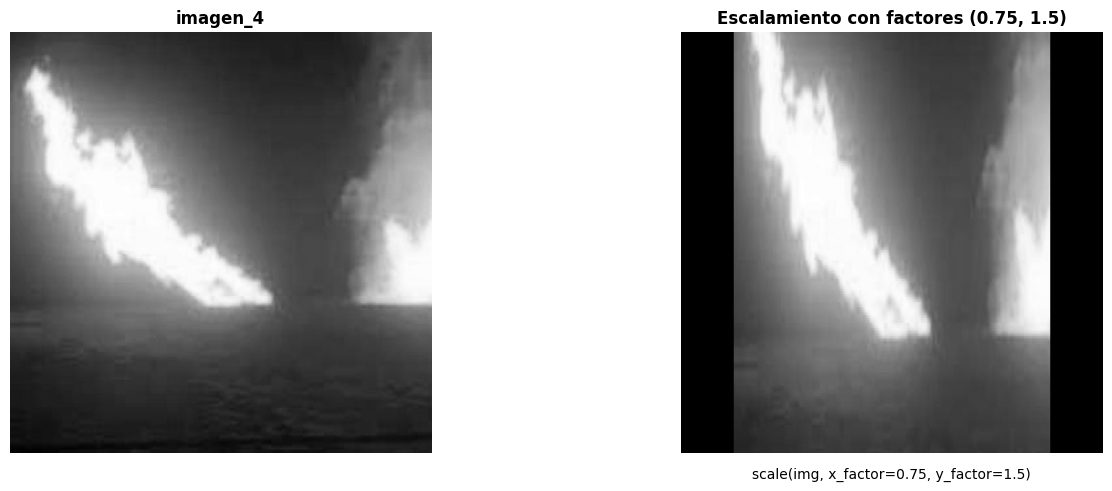

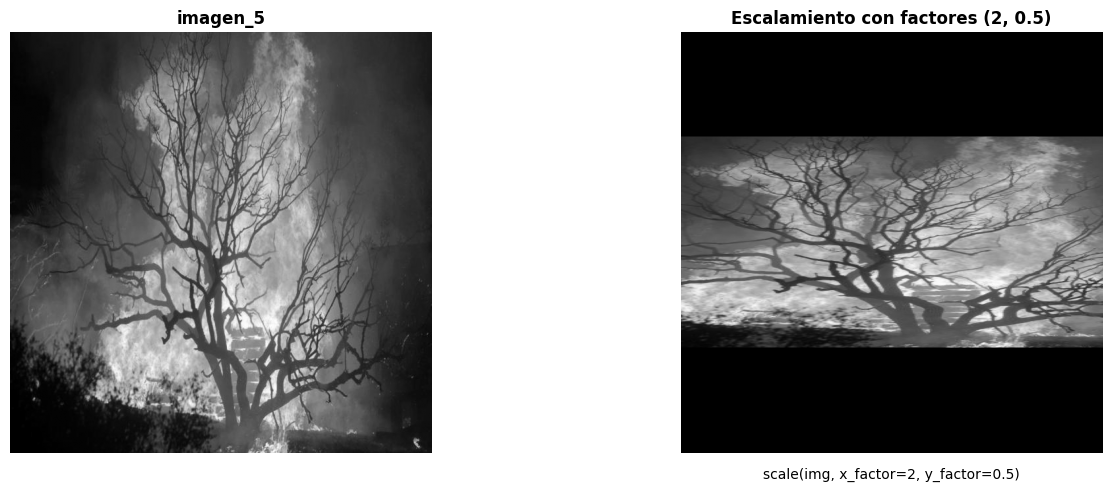

In [6]:
# Mostramos los resultados de diccionario
for key, img in res_esc.items():
    text_esc = f"scale(img, x_factor={factores[int(key.split('_')[1])-1][0]}, y_factor={factores[int(key.split('_')[1])-1][1]})"
    config = [{'imagen': images_bn[int(key.split('_')[1])-1], 'titulo': key},
        {'imagen': img, 'titulo': 'Escalamiento con factores ' + str(factores[int(key.split('_')[1])-1]), 'texto': text_esc, 'texto_pos': (0.5, -0.05)}]
    
    plots_utils.mostrar_imagenes(
        imagenes_config=config,
        figsize=(15, 5),
        cmap='gray'
    )